In [19]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from data_utils import fillna_data
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transform_utils import LightGBM_model
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import mean_absolute_error, f1_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, TargetEncoder, OrdinalEncoder

In [2]:
CATBOOST_HYPERPARAMETRS = {'iterations': 310, 'learning_rate': 0.027840399648168222, 'loss_function': 'MAE', 'depth': 4, 'l2_leaf_reg': 3.92824763942005, 'min_data_in_leaf': 83}
LIGHTGBM_HYPERPARAMETRS = {'learning_rate': 0.06215441032821967, 'num_leaves': 29, 'max_depth': 8, 'n_estimators': 604, 'bagging_fraction': 0.7522409438349638, 'min_child_samples': 286, 'feature_fraction': 0.9990690851708498}

In [57]:
class Trajectory: 
    def __init__(self):
        
        self.grade_model = CatBoostRegressor(**CATBOOST_HYPERPARAMETRS, verbose=False)
        self.cat_features = None
        self.X_columns = None

        self.type_model = LightGBM_model(**LIGHTGBM_HYPERPARAMETRS)

    def _fillna_data(self, data):
        return fillna_data(data)
    
    def _fit_grade(self, data):
        data_filled = self._fillna_data(data)
        X = data_filled.drop(columns=['target_grade', 'target_type'])
        y_grade = data_filled['target_grade']
        
        self.X_columns = X.columns
        self.cat_features = [col for col in X.columns if X[col].dtype == 'object']

        X_pool = Pool(X, y_grade, self.cat_features)
        self.grade_model.fit(X_pool)

        self.type_model.fit(data_filled)

    def predict(self, data):
        data = self._fillna_data(data)
        X = data[self.X_columns]
        grades_pred = self.grade_model.predict(X)
        grades_pred = np.round(self.grade_model.predict(X))

        type_pred=self.type_model.predict_type(data)
        return grades_pred, type_pred 

    def visualize(self, y_true, y_pred):
        fig, axs = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle('Results', fontweight='bold')
  
        axs[0][0].set_title('Real vs. predicted values')
        axs[0][0].scatter(y_true, y_pred, c=np.abs(y_true - y_pred), cmap='summer', s=20)
        axs[0][0].plot(y_true, y_true, color='red', alpha=0.8)
        axs[0][0].set_xlabel('grade')
        axs[0][0].set_ylabel('prediction')
        axs[0][0].grid(alpha=0.3)
        
        axs[0][1].set_title('Prediction errors')
        errors = y_true - y_pred
        bins = np.arange(errors.min() - 0.5, errors.max() + 1.5, 1)
        axs[0][1].hist(errors, bins=bins)
        axs[0][1].axvline(0, color='red', linestyle='--')
        axs[0][1].set_xlabel('error')
        axs[0][1].set_ylabel('count')

        axs[1][0].set_title('Error by sample')
        axs[1][0].scatter(range(len(errors)), errors, c=np.abs(errors), cmap='summer', s=15, alpha=0.7)
        axs[1][0].axhline(0, color='red', linestyle='--', alpha=0.8)
        axs[1][0].set_xlabel('sample index')
        axs[1][0].set_ylabel('error')
        axs[1][0].grid(alpha=0.3)

        axs[1][1].set_title('Grade comparison')
        bins = np.linspace(min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max()), 20)
        axs[1][1].hist(y_true, bins=bins, alpha=0.6, label='true')
        axs[1][1].hist(y_pred, bins=bins, alpha=0.6, label='predicted')
        axs[1][1].legend()
        axs[1][1].set_xlabel('grade')
        axs[1][1].set_ylabel('count')
        plt.tight_layout()
        plt.show()

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)
    
    # мб еще что-то добавить
    

In [25]:
data = pd.read_csv('total_laggs.csv', low_memory=False)

In [26]:
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

test_data1, test_data2= train_test_split(test_data, test_size=0.5, random_state=42, shuffle=True) # ради прикола шаффл написала

Обучаем модель: 

In [58]:
model=Trajectory()
model._fit_grade(train_data)


Предсказываем и посмотрим метрики:

In [40]:
y_pred, y_pred1=model.predict(test_data1)

In [35]:
mean_absolute_error(y_pred, test_data1["target_grade"])

1.2589285714285714

In [36]:
f1_score(y_pred1, test_data1["target_type"], average='weighted')

0.962731847017035

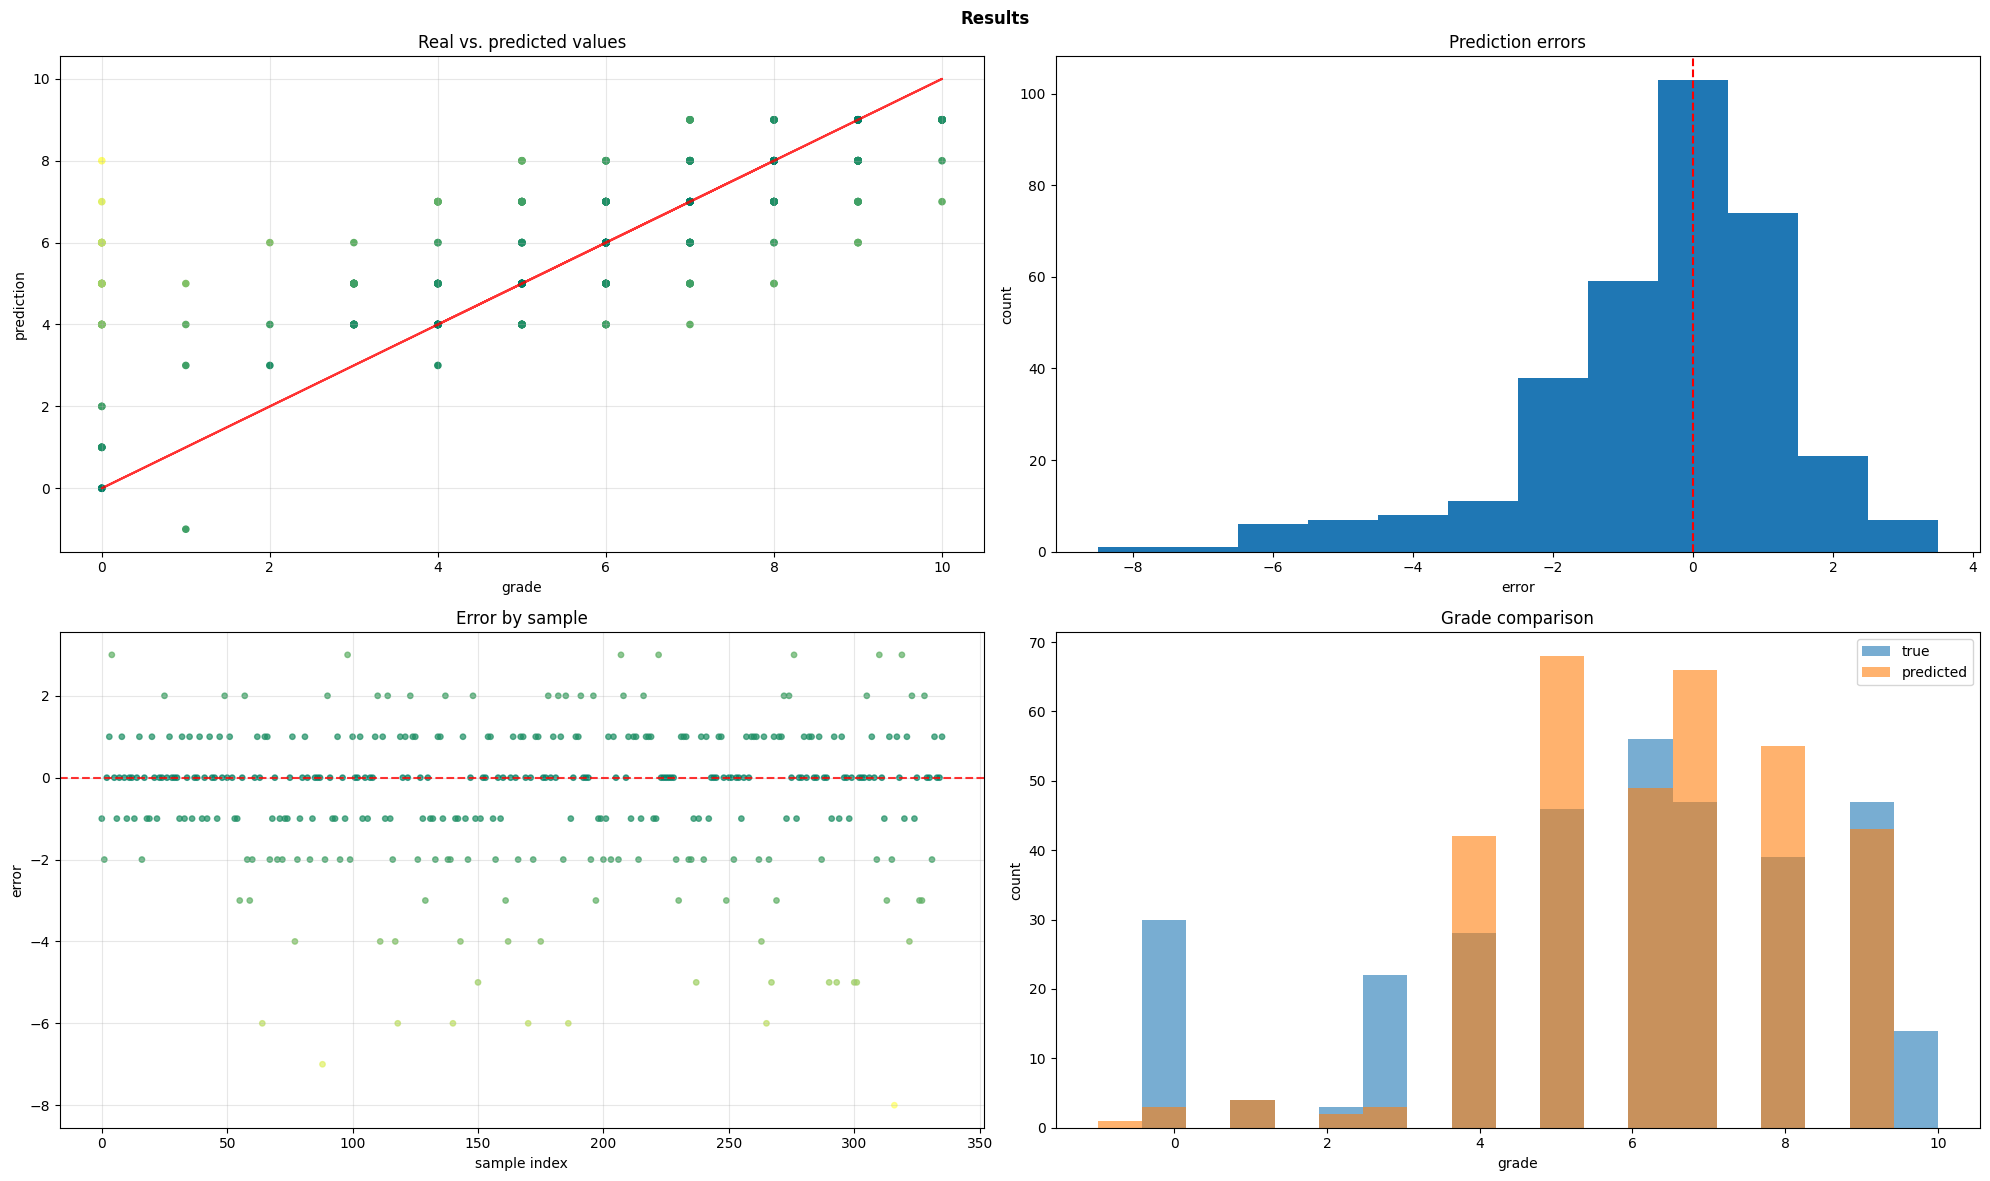

In [59]:
model.visualize(test_data1['target_grade'], y_pred)

Сохраняем модель: 

In [38]:
model.save("trajectory.pkl")

А теперь загрузим сохраненную модель и проверим:

In [39]:
model = Trajectory.load("trajectory.pkl")

In [40]:
y_grade, y_type = model.predict(test_data2)

In [41]:
mean_absolute_error(y_grade, test_data2["target_grade"])

1.181547619047619

In [42]:
f1_score(y_type, test_data2["target_type"], average='weighted')

0.9601521164021165

ураааа ну кажется работает хз...